In [75]:
import numpy as np

In [76]:
npz_path = 'features_and_paths.npz'
data = np.load(npz_path)
features = data['features']
labels = data['paths']
print(labels)

['/content/drive/MyDrive/Public/Honda/22520394-22520395.Honda.216.jpg'
 '/content/drive/MyDrive/Public/Honda/22520394-22520395.Honda.204.jpg'
 '/content/drive/MyDrive/Public/Honda/22520394-22520395.Honda.207.jpg' ...
 '/content/drive/MyDrive/Public/VinFast/22520459-22520507-22520862.VinFast.9.jpg'
 '/content/drive/MyDrive/Public/VinFast/22520459-22520507-22520862.VinFast.33.jpg'
 '/content/drive/MyDrive/Public/VinFast/22520459-22520507-22520862.VinFast.24.jpg']


In [77]:
LABEL = {
    'Others': 0,
    'Honda': 1,
    'Hyundai': 2,
    'KIA': 3,
    'Mazda': 4,
    'Mitsubishi': 5,
    'Suzuki': 6,
    'Toyota': 7,
    'VinFast': 8,
}


numerical_labels = []
for path in labels:
    brand = path.split('/')[-2] 
    assert(brand in LABEL)
    numerical_labels.append(LABEL[brand])

labels = np.array(numerical_labels)

print(features.shape)
print(labels.shape)

(37785, 1280)
(37785,)


In [78]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

class MultiClassModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MultiClassModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [79]:
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Create TensorDatasets
train_dataset = TensorDataset(torch.tensor(features_train, dtype=torch.float32), torch.tensor(labels_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(features_test, dtype=torch.float32), torch.tensor(labels_test, dtype=torch.long))

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [80]:
input_size = features.shape[1]
num_classes = len(torch.unique(torch.tensor(labels, dtype=torch.long)))
model = MultiClassModel(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [81]:
num_epochs = 20
loss_values = []
for epoch in range(num_epochs):
    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_values.append(loss.item())


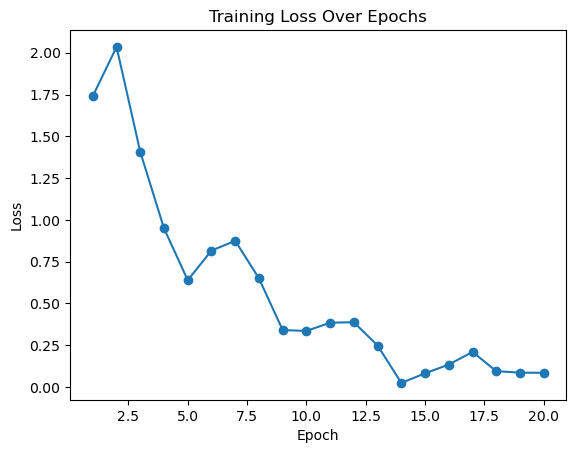

In [82]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), loss_values, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

In [83]:

model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    correct = 0
    total = 0
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
        all_labels.extend(batch_labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

    print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 56.78%


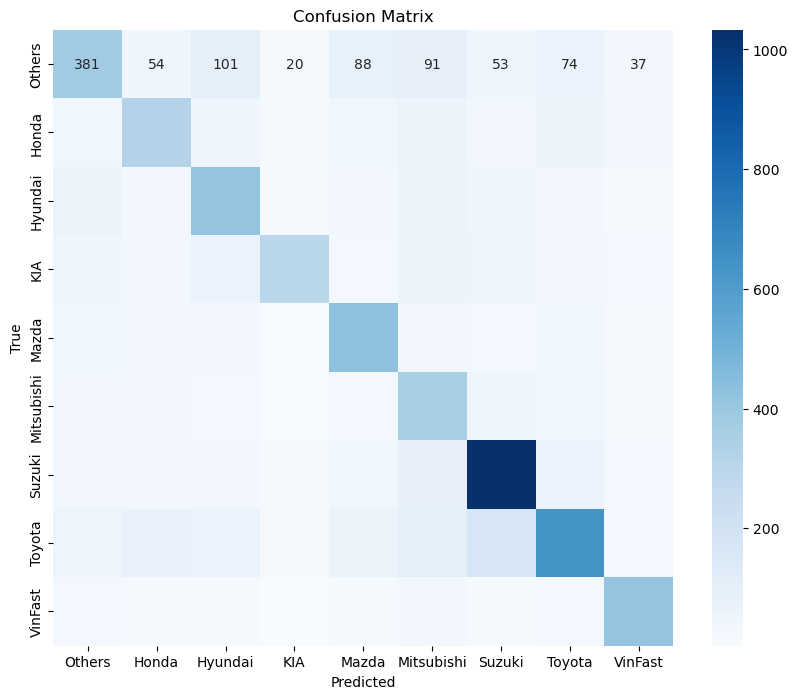

In [107]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_matrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(LABEL.keys()),
    yticklabels=list(LABEL.keys()),
    annot_kws={"size": 10}  # Customize annotation size
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [108]:
print(conf_matrix)

[[ 381   54  101   20   88   91   53   74   37]
 [  41  318   50   19   42   65   35   64   35]
 [  67   36  417   22   39   66   50   40   21]
 [  49   40   75  298   31   64   59   39   29]
 [  44   35   39   13  434   38   29   42   19]
 [  39   38   29    9   25  354   55   44   21]
 [  35   39   33   19   46   90 1033   69   30]
 [  60   77   75   17   65  104  175  638   32]
 [  31   18   20    4   23   39   22   28  418]]
